# Comparacion edge-based

Esta notebook compara tres escenarios chicos para entender cuando `EDGE_BY_EDGE` y `EDGE_TO_EDGE` convergen o se separan a nivel de planning.

Los tres casos son:

1. `01_edge_by_edge_wins`: una cadena dirigida de cuatro grupos adyacentes. `EdBEd` gana globalmente porque reutiliza solo fronteras fisicas reales.
2. `02_tie_two_groups`: dos grupos con salto directo en ambos sentidos. Ambos modelos coinciden.
3. `03_edge_to_edge_route_advantage`: una cadena dirigida de tres grupos. Sobre la ruta `G1 -> G2 -> G3`, `Ed2Ed` comprime mejor la ruta puntual (`G1-G3` en vez de `G1-G2` y `G2-G3`), aunque globalmente el planning no mejora.

La idea es separar con claridad **ventaja global de planning** vs **ventaja local sobre una ruta concreta**.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

SCENARIO_DIR = Path.cwd()
REPO_ROOT = SCENARIO_DIR.parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline

sns.set_theme(style="whitegrid")

MODEL_PALETTE = {
    "HOP_BY_HOP": "#4c78a8",
    "END_TO_END": "#f58518",
    "EDGE_BY_EDGE": "#54a24b",
    "EDGE_TO_EDGE": "#e45756",
}

DISPLAY_NAME = {
    "HOP_BY_HOP": "HBH",
    "END_TO_END": "E2E",
    "EDGE_BY_EDGE": "EdBEd",
    "EDGE_TO_EDGE": "Ed2Ed",
}

SCENARIOS = {
    "01_edge_by_edge_wins": {
        "title": "EdBEd gana globalmente",
        "max_routes": 1,
    },
    "02_tie_two_groups": {
        "title": "Empate",
        "max_routes": 1,
    },
    "03_edge_to_edge_route_advantage": {
        "title": "Ed2Ed mejora una ruta, no el planning global",
        "max_routes": 1,
    },
}


In [6]:
def run_scenario(folder_name: str, max_routes: int):
    scenario_path = SCENARIO_DIR / folder_name
    return SimulationPipeline().run(
        cp_path=str(scenario_path / "contact_plan.json"),
        topology_path=str(scenario_path / "topology.json"),
        security_models=tuple(SecurityModelType),
        curr_time=0,
        routing_algorithm=CGRYenRouting(max_routes=max_routes),
    )


results = {
    folder_name: run_scenario(folder_name, config["max_routes"])
    for folder_name, config in SCENARIOS.items()
}

rows = []
for folder_name, sim_result in results.items():
    for model in SecurityModelType:
        unique_keys = len(
            {
                req.scope
                for pair in sim_result.security.pairs
                for plan in sim_result.security.plans_by_model[model][pair]
                for req in plan.key_requirements
            }
        )
        rows.append(
            {
                "scenario": folder_name,
                "scenario_title": SCENARIOS[folder_name]["title"],
                "model": model.name,
                "model_display": DISPLAY_NAME[model.name],
                "unique_keys": unique_keys,
            }
        )

df = pd.DataFrame(rows)
df


,scenario,scenario_title,model,model_display,unique_keys
0,01_edge_by_edge_wins,EdBEd gana globalmente,HOP_BY_HOP,HBH,3
1,01_edge_by_edge_wins,EdBEd gana globalmente,END_TO_END,E2E,6
2,01_edge_by_edge_wins,EdBEd gana globalmente,EDGE_BY_EDGE,EdBEd,3
3,01_edge_by_edge_wins,EdBEd gana globalmente,EDGE_TO_EDGE,Ed2Ed,6
4,02_tie_two_groups,Empate,HOP_BY_HOP,HBH,2
5,02_tie_two_groups,Empate,END_TO_END,E2E,2
6,02_tie_two_groups,Empate,EDGE_BY_EDGE,EdBEd,2
7,02_tie_two_groups,Empate,EDGE_TO_EDGE,Ed2Ed,2
8,03_edge_to_edge_route_advantage,"Ed2Ed mejora una ruta, no el planning global",HOP_BY_HOP,HBH,2
9,03_edge_to_edge_route_advantage,"Ed2Ed mejora una ruta, no el planning global",END_TO_END,E2E,3


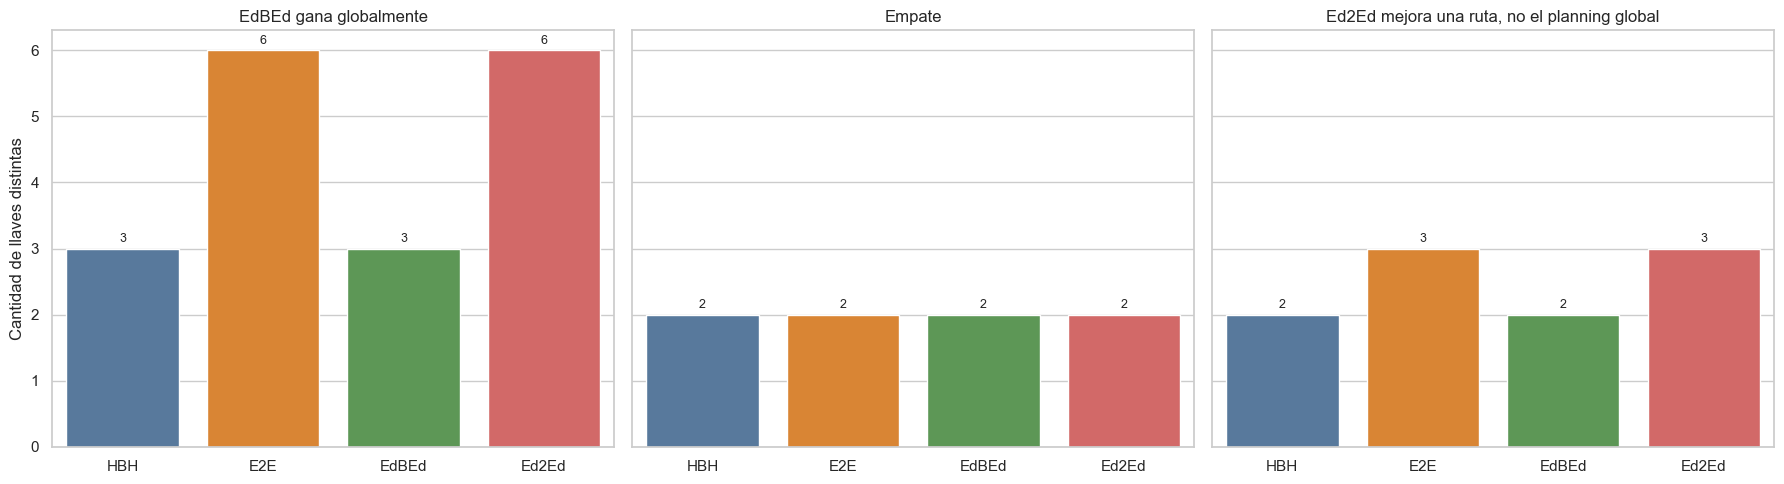

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plot_order = ["HOP_BY_HOP", "END_TO_END", "EDGE_BY_EDGE", "EDGE_TO_EDGE"]

for ax, (folder_name, config) in zip(axes, SCENARIOS.items()):
    scenario_df = df[df["scenario"] == folder_name].copy()
    scenario_df["model"] = pd.Categorical(scenario_df["model"], categories=plot_order, ordered=True)
    scenario_df = scenario_df.sort_values("model")

    sns.barplot(
        data=scenario_df,
        x="model_display",
        y="unique_keys",
        hue="model",
        dodge=False,
        palette=MODEL_PALETTE,
        legend=False,
        ax=ax,
    )

    ax.set_title(config["title"])
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad de llaves distintas" if ax is axes[0] else "")

    for patch in ax.patches:
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + 0.05,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()


In [8]:
route_level_pair = (1, 3)
route_level_result = results["03_edge_to_edge_route_advantage"]
annotated = route_level_result.annotation.annotated_routes_by_pair[route_level_pair][0]
ebe_plan = route_level_result.security.plans_by_model[SecurityModelType.EDGE_BY_EDGE][route_level_pair][0]
ete_plan = route_level_result.security.plans_by_model[SecurityModelType.EDGE_TO_EDGE][route_level_pair][0]

pd.DataFrame(
    [
        {
            "model": "EdBEd",
            "node_path": str(annotated.node_path),
            "network_path": str(annotated.network_path),
            "key_requirements": ", ".join(str(req) for req in ebe_plan.key_requirements),
        },
        {
            "model": "Ed2Ed",
            "node_path": str(annotated.node_path),
            "network_path": str(annotated.network_path),
            "key_requirements": ", ".join(str(req) for req in ete_plan.key_requirements),
        },
    ]
)


,model,node_path,network_path,key_requirements
0,EdBEd,"(1, 2, 3)","(1, 2, 3)","GROUP_TO_GROUP(1->2), GROUP_TO_GROUP(2->3)"
1,Ed2Ed,"(1, 2, 3)","(1, 2, 3)",GROUP_TO_GROUP(1->3)


## Lectura rapida

- En `01_edge_by_edge_wins`, la cadena dirigida de grupos hace que `EdBEd` reutilice solo fronteras adyacentes reales, mientras `Ed2Ed` agrega relaciones logicas `G-G` origen-destino y crece mas.
- En `02_tie_two_groups`, como solo existe una frontera inter-red, ambos modelos inducen el mismo universo de llaves.
- En `03_edge_to_edge_route_advantage`, la ruta `1 -> 2 -> 3` muestra una compresion local genuina de `Ed2Ed`: `EdBEd` necesita `G1-G2` y `G2-G3`, mientras `Ed2Ed` usa solo `G1-G3`.

Ese tercer caso es util para separar claramente dos preguntas distintas:

1. que pasa sobre una ruta puntual;
2. que pasa sobre el cierre global de rutas candidatas del escenario.